<h1>NAO Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/mslp/'

In [4]:
ufs_vars_list = ['slp', 'prmsl']
era5_var = 'mean_sea_level_pressure'
seas5_var = 'msl'

In [5]:
ufs_experiments = ['baseline', 'beta.0.1', 'cpc_ics']

In [6]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [7]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [8]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [9]:
# Get ERA5 data
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [10]:
# The .describe() method prints out a summary of your dataset, or of 1 variable
# seas5_data_reader.describe()
# seas5_data_reader.describe(seas5_var)

<h5>Define time period</h5>

In [11]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonths = (11,)

In [12]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

<h5>Get SFS data</h5>

In [13]:
%%capture captured_output
ufs_ds_1 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_1, initmonths=initmonths, flatten=True).load()

ufs_ds_2 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_2, initmonths=initmonths, flatten=True).load()

<h5>Get the corresponding ERA5 data</h5>

In [14]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                lat=region_1['latmin'],
                lon=region_1['lonmin'],
                time=time_range).squeeze(['lat', 'lon']).load()  # flatten

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                lat=region_2['latmin'],
                lon=region_2['lonmin'],
                time=time_range).squeeze(['lat', 'lon']).load()  # flatten


In [15]:
seas5_ds_1 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_1['latmin'],
                                        lon=region_1['lonmin'],
                                        initmonths=initmonths,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

seas5_ds_2 = seas5_data_reader.retrieve(var=seas5_var,
                                        lat=region_2['latmin'],
                                        lon=region_2['lonmin'],
                                        initmonths=initmonths,
                                        time=time_range,
                                        member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                        ens_avg=True).squeeze(['lat', 'lon']).load()  # flatten

Taking Ensemble Average
Taking Ensemble Average


In [16]:
# Because both the seas5 and ufs models have init+lead structure,
# combine seas5 into the ufs dataset as a standalone "member"

# Rename to match ufs
seas5_ds_1 = seas5_ds_1.rename({'msl': 'slp'})
seas5_ds_2 = seas5_ds_2.rename({'msl': 'slp'})

# consider ecmwf a 'member'
seas5_ds_1 = seas5_ds_1.assign_coords(member=('member', ['seas5']))
seas5_ds_2 = seas5_ds_2.assign_coords(member=('member', ['seas5']))

# Concatenate with ufs
ufs_ds_1 = xr.concat([ufs_ds_1, seas5_ds_1], dim='member', coords='minimal', compat='equals')
ufs_ds_2 = xr.concat([ufs_ds_2, seas5_ds_2], dim='member', coords='minimal', compat='equals')

# Reorder member dimension in the way we want.
ufs_experiments.insert(2, 'seas5')
ufs_ds_1 = ufs_ds_1.reindex(member=ufs_experiments)
ufs_ds_2 = ufs_ds_2.reindex(member=ufs_experiments)

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [17]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=True)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=True)

In [18]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

Normalize the data. z = (X - mu) / sigma

In [19]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_vars_list[0]], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_vars_list[0]], stats=ufs_stats_2)

In [20]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h1>Calculate NAO Index</h1>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [21]:
ufs_ds_nao = (ufs_da_2 - ufs_da_1).to_dataset()
era5_ds_nao = (era5_da_2 - era5_da_1).to_dataset()

<h1>Plot NAO Index</h1>

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2021


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/copernicus/lib/python3.11/site-packages/matplotlib/pyplot.py'>

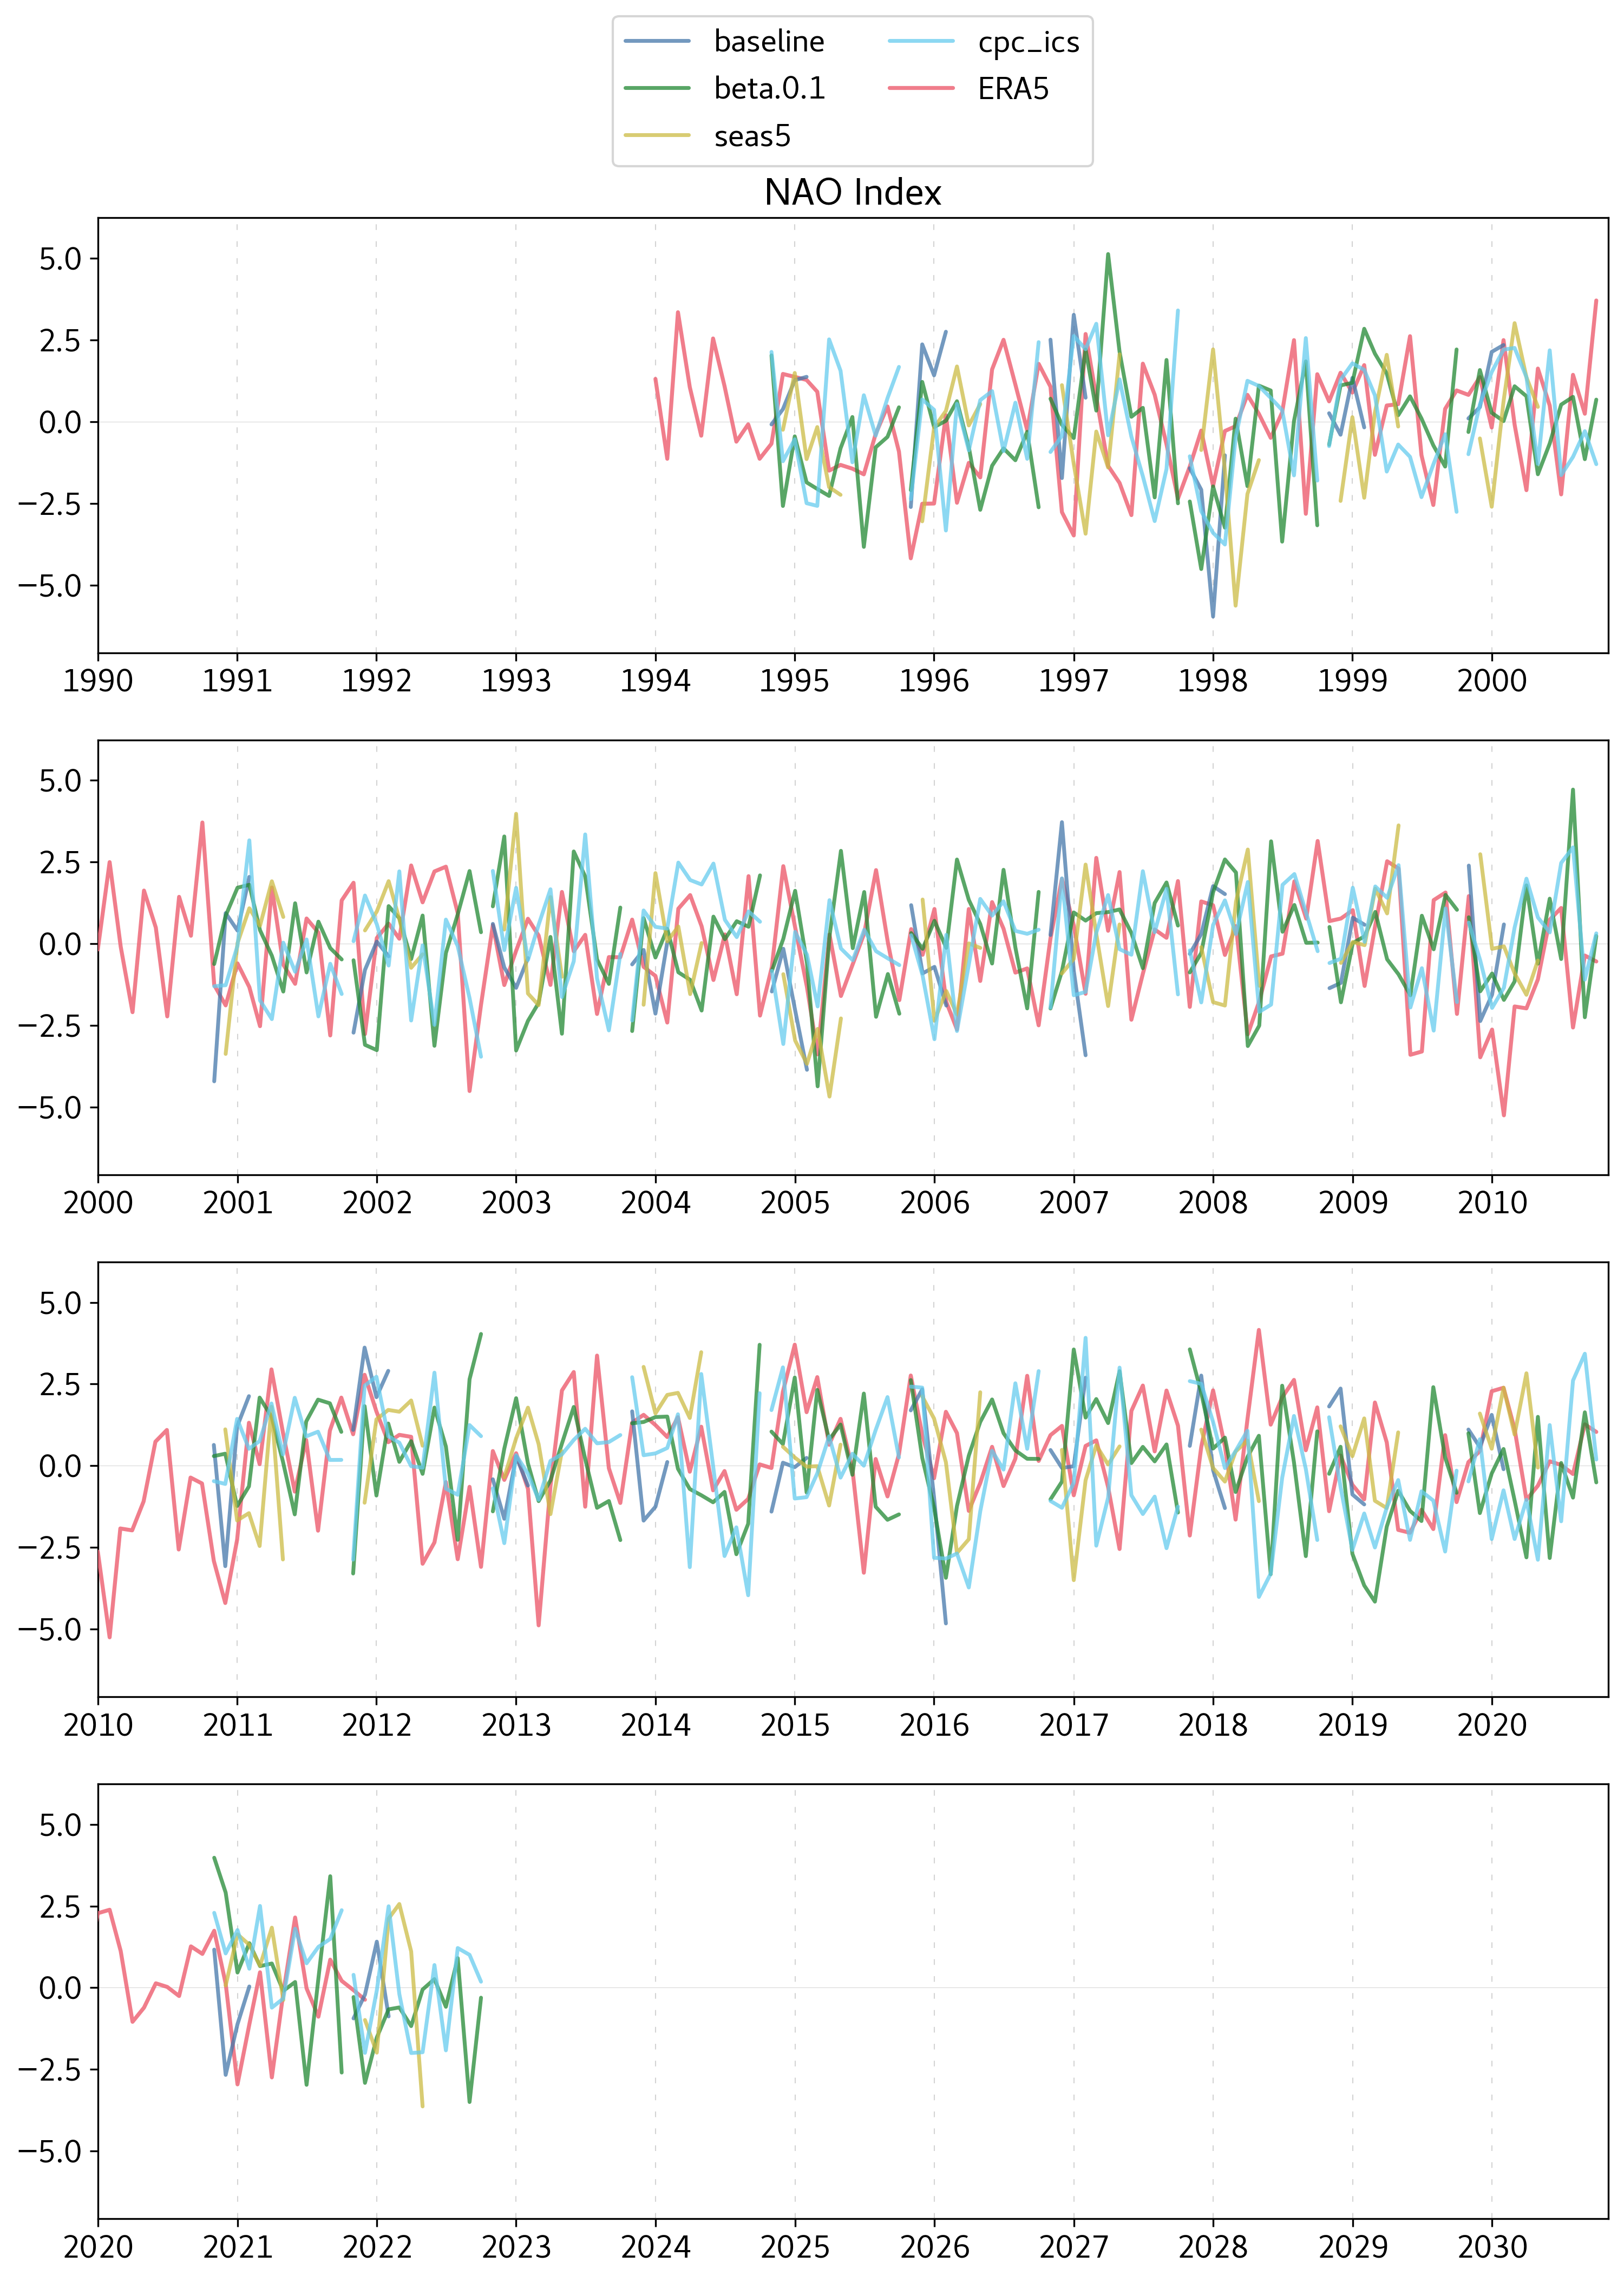

In [22]:
stats.plot_index_spaghetti(ufs_stats={'monthly_mean': ufs_ds_nao[ufs_vars_list[0]]},
                           verif_stats={'monthly_mean': era5_ds_nao[era5_var]},
                           calc_anomaly=False,
                           title=f'NAO Index',
                           verif_label='ERA5',
                           dpi=300)